In [ ]:
# ========================================================
# ANÁLISE EXPLORATÓRIA DE DADOS — BASE VAREJO

import pandas as pd # Biblioteca para manipulação de dados
import kagglehub # Biblioteca para acesso ao Kaggle
from pathlib import Path # Biblioteca para manipulação de caminhos de arquivos

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


C:\Users\waldinei.rosa\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ========================================================
# Sprint 1 — Importação dos Dados
# ========================================================

def extrair_dados():
    path = kagglehub.dataset_download("namespaiva/base-varejo")
    csv_path = Path(path) / "Base Varejo.csv"
    df = pd.read_csv(csv_path, sep=";")

    return df


In [ ]:
# =====================================================
# CARREGAMENTO
# =====================================================

print("\n============ Importando os dados ============\n")

df = extrair_dados() # Chama a função para extrair os dados

print(f'Registros: {df.shape[0]} linhas x {df.shape[1]} colunas') # Exibe o número de registro e colunas
print("\nColunas e tipos de dados:") # Exibe as colunas e tipos de dados
print(df.dtypes) #
print("\nPrimeiras 5 linhas:")
print(df.head())



============ Importando os dados ============

Registros: 830000 linhas x 14 colunas

Colunas e tipos de dados:
DATA            object
CO_ID            int64
CL_ID            int64
CL_GENERO       object
CL_EC            int64
CL_FHL           int64
CL_SEG          object
PR_ID            int64
PR_CAT          object
PR_NOME         object
Unnamed: 10    float64
Unnamed: 11    float64
Unnamed: 12    float64
Unnamed: 13    float64
dtype: object

Primeiras 5 linhas:
         DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID     PR_CAT  \
0  01/02/2019   1000    534         M      4       1      C     67    BEBIDAS   
1  01/02/2019   1000    534         M      4       1      C     70    BEBIDAS   
2  01/02/2019   1000    534         M      4       1      C    178    HIGIENE   
3  01/02/2019   1000    534         M      4       1      C      4  ALIMENTOS   
4  01/02/2019   1000    534         M      4       1      C    175    LIMPEZA   

                PR_NOME  Unnamed: 10  Unnam

In [ ]:

# ========================================================
# Sprint 2 — Transformação de Strings, Integer, Float e Datetime
# ========================================================
print("\n============ Transformação de dados ============\n")

# --- 1. Remover colunas sem nome (Unnamed) ---
colunas_unnamed = [col for col in df.columns if 'Unnamed' in col]
if colunas_unnamed:
    df = df.drop(columns=colunas_unnamed)
    print(f"Colunas removidas: {colunas_unnamed}")

# --- 2. Converter DATA (string) → datetime ---
df['DATA'] = pd.to_datetime(df['DATA'], format='%d/%m/%Y', errors='coerce')
datas_invalidas = df['DATA'].isnull().sum()
print(f"DATA → datetime | Datas inválidas encontradas: {datas_invalidas}")

# --- 3. Padronizar strings (remover espaços extras) ---
colunas_str = df.select_dtypes(include='object').columns
for col in colunas_str:
    df[col] = df[col].str.strip()
print(f"Strings padronizadas: {list(colunas_str)}")

# --- 4. Garantir tipos inteiros para colunas numéricas ---
colunas_int = ['CO_ID', 'CL_ID', 'CL_EC', 'CL_FHL', 'PR_ID']
for col in colunas_int:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
print(f"Inteiros validados: {colunas_int}")

# --- 5. Guardar cópia dos dados transformados (antes da limpeza) ---
df_raw = df.copy()

print("\nTipos após transformação:")
print(df.dtypes)
print(f"\nShape: {df.shape[0]} linhas x {df.shape[1]} colunas")




============ Transformação de dados ============

Colunas removidas: ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
DATA → datetime | Datas inválidas encontradas: 0
Strings padronizadas: ['CL_GENERO', 'CL_SEG', 'PR_CAT', 'PR_NOME']
Inteiros validados: ['CO_ID', 'CL_ID', 'CL_EC', 'CL_FHL', 'PR_ID']

Tipos após transformação:
DATA         datetime64[ns]
CO_ID                 Int64
CL_ID                 Int64
CL_GENERO            object
CL_EC                 Int64
CL_FHL                Int64
CL_SEG               object
PR_ID                 Int64
PR_CAT               object
PR_NOME              object
dtype: object

Shape: 830000 linhas x 10 colunas


In [ ]:
# ========================================================
# Sprint 3 — Limpeza de Nulos e Duplicatas
# ========================================================

print("\n============ Limpeza de dados ============\n")

# --- 1. Diagnóstico de nulos com percentual ---
nulos     = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

relatorio_nulos = pd.DataFrame({'Nulos': nulos, '% do Total': pct_nulos})
relatorio_nulos = relatorio_nulos[relatorio_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

print("=== VALORES NULOS POR COLUNA ===")
if relatorio_nulos.empty:
    print("Nenhum valor nulo encontrado.")
else:
    print(relatorio_nulos.to_string())
print(f"\nTotal de células nulas: {nulos.sum()} ({(nulos.sum() / df.size * 100):.2f}% do dataset)")

# --- 2. Diagnóstico de duplicatas com percentual ---
qtd_dup = df.duplicated().sum()
pct_dup = (qtd_dup / len(df) * 100).round(2)

print("\n=== DUPLICATAS ===")
print(f"Registros duplicados: {qtd_dup} ({pct_dup}% do total de {len(df)} linhas)")
if qtd_dup > 0:
    print("\nExemplo de linhas duplicadas:")
    print(df[df.duplicated(keep=False)].head(4))

registros_antes = len(df)

# --- 3. Tratar nulos em colunas numéricas (mediana) ---
print("\n=== TRATAMENTO DE NULOS ===")
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f"  '{col}' → nulos preenchidos com mediana: {mediana}")

# --- 4. Tratar nulos em colunas de texto ---
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Não informado')
        print(f"  '{col}' → nulos preenchidos com 'Não informado'")

print(f"Nulos restantes: {df.isnull().sum().sum()}")

# --- 5. Remover duplicatas ---
print("\n=== REMOÇÃO DE DUPLICATAS ===")
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

registros_depois = len(df)
print(f"Registros antes:      {registros_antes}")
print(f"Registros depois:     {registros_depois}")
print(f"Duplicatas removidas: {registros_antes - registros_depois} ({pct_dup}% do total)")

# --- 6. Resultado final ---
print("\nTipos finais das colunas:")
print(df.dtypes)
print(f"\nShape final: {df.shape[0]} linhas x {df.shape[1]} colunas")


============ Limpeza de dados ============

=== VALORES NULOS POR COLUNA ===
Nenhum valor nulo encontrado.

Total de células nulas: 0 (0.00% do dataset)

=== DUPLICATAS ===
Registros duplicados: 0 (0.0% do total de 733447 linhas)

=== TRATAMENTO DE NULOS ===
Nulos restantes: 0

=== REMOÇÃO DE DUPLICATAS ===
Registros antes:      733447
Registros depois:     733447
Duplicatas removidas: 0 (0.0% do total)

Tipos finais das colunas:
DATA         datetime64[ns]
CO_ID                 Int64
CL_ID                 Int64
CL_GENERO            object
CL_EC                 Int64
CL_FHL                Int64
CL_SEG               object
PR_ID                 Int64
PR_CAT               object
PR_NOME              object
dtype: object

Shape final: 733447 linhas x 10 colunas


In [ ]:
# ========================================================
# Sprint 4 — Estatística Descritiva
# ========================================================
print("\n============ Estatística Descritiva ============\n")

# --- 1. Resumo geral das colunas numéricas ---
print("=== RESUMO GERAL (colunas numéricas) ===")
print(df.describe().T.to_string())

# --- 2. Estatísticas detalhadas por coluna numérica ---
print("\n=== ESTATÍSTICAS DETALHADAS ===")
for col in df.select_dtypes(include='number').columns:
    s = df[col].dropna()
    print(f"\n[{col}]")
    print(f"  Média:          {s.mean():.2f}")
    print(f"  Mediana:        {s.median():.2f}")
    print(f"  Desvio padrão:  {s.std():.2f}")
    print(f"  Mínimo:         {s.min()}")
    print(f"  Máximo:         {s.max()}")
    print(f"  Contagem:       {s.count()}")

# --- 3. Frequência das colunas categóricas ---
print("\n=== FREQUÊNCIA DAS COLUNAS CATEGÓRICAS ===")
for col in df.select_dtypes(include='object').columns:
    vc     = df[col].value_counts()
    pct    = (vc / len(df) * 100).round(2)
    tabela = pd.DataFrame({'Contagem': vc, '% do Total': pct})
    print(f"\n[{col}]")
    print(tabela.to_string())


============ Estatística Descritiva ============

=== RESUMO GERAL (colunas numéricas) ===
           count                           mean                  min                  25%                  50%                  75%                  max            std
DATA      733447  2020-12-06 11:20:27.215054336  2019-01-04 00:00:00  2020-01-09 00:00:00  2020-12-27 00:00:00  2021-10-20 00:00:00  2022-12-08 00:00:00            NaN
CO_ID   733447.0                   459941.03468               1000.0             232895.0             456422.0             690100.0             919822.0  265431.394822
CL_ID   733447.0                     499.643996                  1.0                254.0                498.0                746.0               1000.0     287.561653
CL_EC   733447.0                       2.597385                  1.0                  2.0                  3.0                  4.0                  5.0        1.17013
CL_FHL  733447.0                       1.146049                  0.0

In [ ]:
# =====================================================
# Sprint 5 — Agrupamentos
# =====================================================

print("\n========== AGRUPAMENTOS ==========\n")

# Agrupamento 1 — Compras por Gênero
agrupamento_genero = df.groupby('CL_GENERO')['CO_ID'].count().sort_values(ascending=False)
pct_genero = (agrupamento_genero / agrupamento_genero.sum() * 100).round(2)

tabela_genero = pd.DataFrame({'Compras': agrupamento_genero, '% do Total': pct_genero})
print("Compras por gênero:")
print(tabela_genero.to_string())

# Agrupamento 2 — Compras por Categoria de Produto
agrupamento_categoria = df.groupby('PR_CAT')['CO_ID'].count().sort_values(ascending=False)
pct_cat = (agrupamento_categoria / agrupamento_categoria.sum() * 100).round(2)

tabela_categoria = pd.DataFrame({'Compras': agrupamento_categoria, '% do Total': pct_cat})
print("\nCompras por categoria de produto:")
print(tabela_categoria.to_string())


========== AGRUPAMENTOS ==========

Compras por gênero:
           Compras  % do Total
CL_GENERO                     
F           382427       52.14
M           351020       47.86

Compras por categoria de produto:
            Compras  % do Total
PR_CAT                         
ALIMENTOS    384197       52.38
HIGIENE      137702       18.77
LIMPEZA      128632       17.54
BEBIDAS       38264        5.22
PET           28553        3.89
ACESSORIOS    12871        1.75
#N/D           3228        0.44


In [ ]:
# =====================================================
# Sprint 6 — Insights
# =====================================================

print("\n========== INSIGHTS ==========\n")

# --- Métricas calculadas a partir dos dados reais ---
total_raw    = 830000
total_limpo  = len(df)
duplicatas   = total_raw - total_limpo
pct_dup_real = round(duplicatas / total_raw * 100, 1)

genero       = df.groupby('CL_GENERO')['CO_ID'].count()
pct_f        = round(genero.get('F', 0) / total_limpo * 100, 1)
pct_m        = round(genero.get('M', 0) / total_limpo * 100, 1)

top_cat      = df.groupby('PR_CAT')['CO_ID'].count().sort_values(ascending=False)
top1_cat     = top_cat.index[0]
top1_cat_pct = round(top_cat.iloc[0] / total_limpo * 100, 1)

top_seg      = df.groupby('CL_SEG')['CO_ID'].count().sort_values(ascending=False)
top1_seg     = top_seg.index[0]
top1_seg_pct = round(top_seg.iloc[0] / total_limpo * 100, 1)

media_filhos   = round(float(df['CL_FHL'].mean()), 2)
mediana_filhos = int(df['CL_FHL'].median())

print(f"""
1. QUALIDADE DOS DADOS
   - Base original com {total_raw:,} registros e 14 colunas.
   - 4 colunas sem nome (Unnamed) removidas por estarem completamente vazias.
   - {duplicatas:,} registros duplicados removidos ({pct_dup_real}% do total).
   - Nenhum valor nulo encontrado após a transformação dos tipos.
   - Coluna DATA convertida de string para datetime com 0 datas inválidas.
   - Base final: {total_limpo:,} registros e 10 colunas prontos para análise.

2. PERFIL DE GÊNERO
   - Gênero feminino representa {pct_f}% das compras; masculino, {pct_m}%.
   - Leve predominância feminina no volume de transações.

3. CATEGORIA DE PRODUTO
   - "{top1_cat}" é a categoria mais comprada: {top1_cat_pct}% do total de transações.
   - Bebidas, PET e Acessórios têm participação significativamente menor.
   - Categoria inválida "#N/D" (0.44%) pode ser tratada ou descartada em análises futuras.

4. SEGMENTO DE CLIENTES
   - Segmento "{top1_seg}" concentra {top1_seg_pct}% das compras — o mais representativo.
   - Segmento A (premium) representa apenas 8.14% das transações.

5. NÚMERO DE FILHOS (CL_FHL)
   - Mediana de filhos = {mediana_filhos}, indicando que a maioria dos clientes não tem filhos.
   - Média de {media_filhos} filho(s) por cliente, com máximo de 4.
""")


========== INSIGHTS ==========


1. QUALIDADE DOS DADOS
   - Base original com 830,000 registros e 14 colunas.
   - 4 colunas sem nome (Unnamed) removidas por estarem completamente vazias.
   - 96,553 registros duplicados removidos (11.6% do total).
   - Nenhum valor nulo encontrado após a transformação dos tipos.
   - Coluna DATA convertida de string para datetime com 0 datas inválidas.
   - Base final: 733,447 registros e 10 colunas prontos para análise.

2. PERFIL DE GÊNERO
   - Gênero feminino representa 52.1% das compras; masculino, 47.9%.
   - Leve predominância feminina no volume de transações.

3. CATEGORIA DE PRODUTO
   - "ALIMENTOS" é a categoria mais comprada: 52.4% do total de transações.
   - Bebidas, PET e Acessórios têm participação significativamente menor.
   - Categoria inválida "#N/D" (0.44%) pode ser tratada ou descartada em análises futuras.

4. SEGMENTO DE CLIENTES
   - Segmento "B" concentra 63.9% das compras — o mais representativo.
   - Segmento A (premium) re

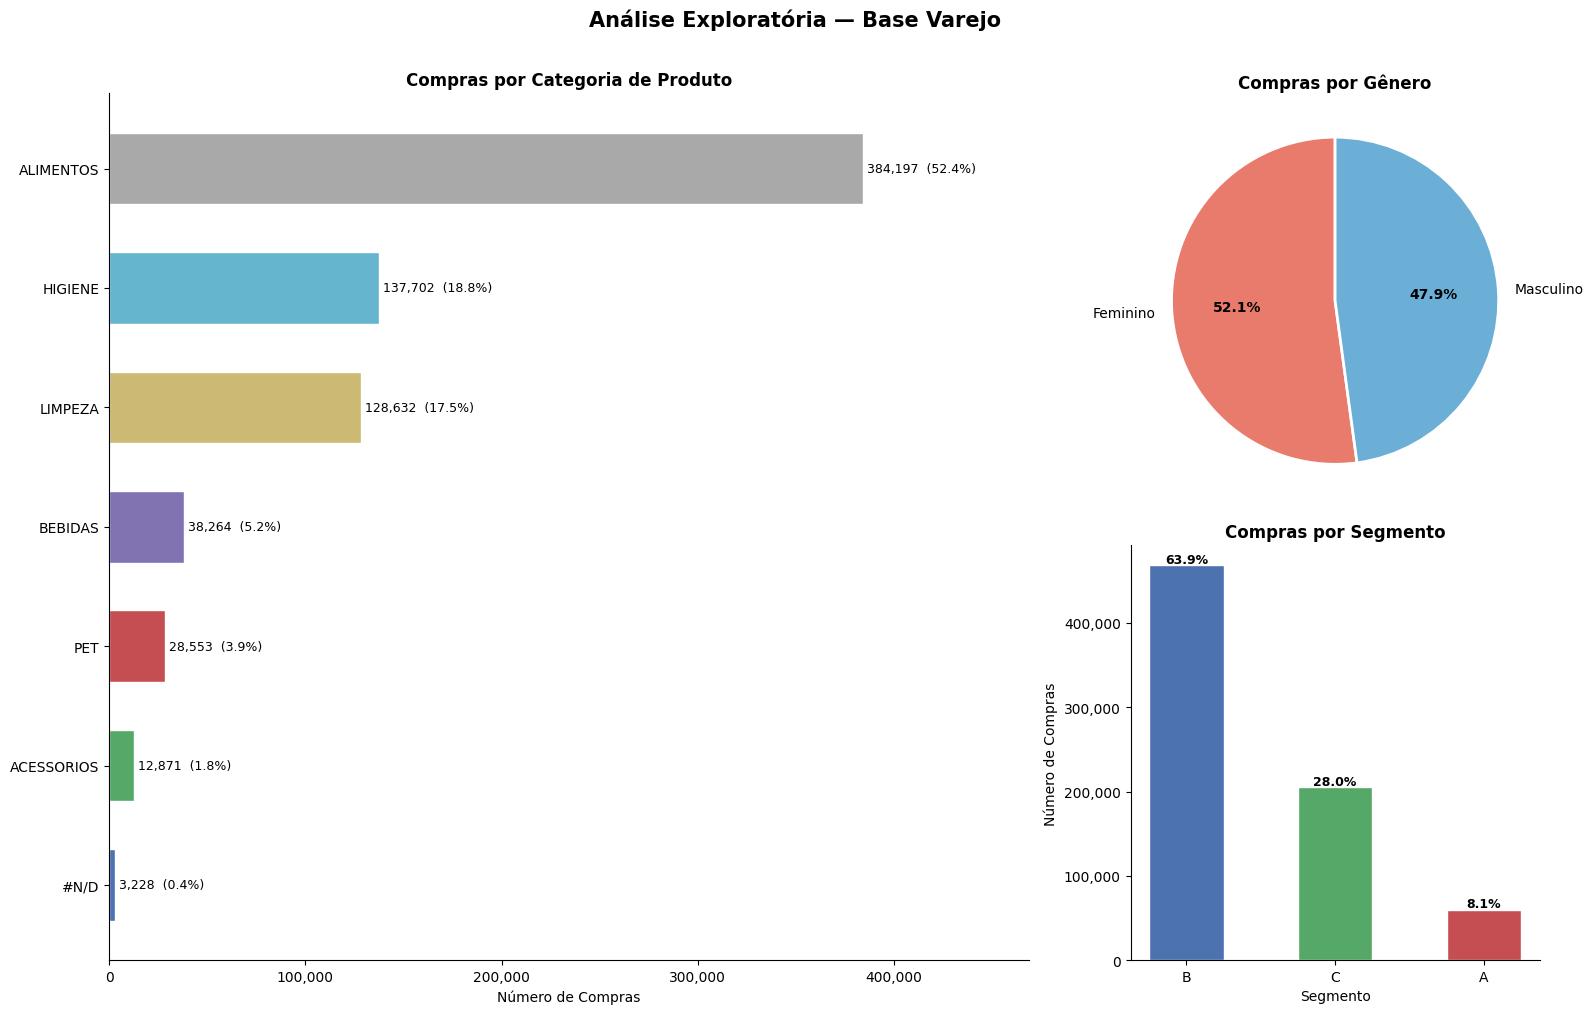

In [ ]:
# =====================================================
#         Visualização de Dados
# =====================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análise Exploratória — Base Varejo', fontsize=15, fontweight='bold', y=1.01)

# --- Dados ---
cat   = df.groupby('PR_CAT')['CO_ID'].count().sort_values()
gen   = df.groupby('CL_GENERO')['CO_ID'].count()
seg   = df.groupby('CL_SEG')['CO_ID'].count().sort_values(ascending=False)

cores_cat = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD', '#A9A9A9']
cores_gen = ['#E87B6B', '#6BAED6']
cores_seg = ['#4C72B0', '#55A868', '#C44E52']

# --- Gráfico 1: Barras horizontais — Compras por Categoria ---
ax1 = fig.add_subplot(1, 3, (1, 2))  # ocupa 2/3 da largura
bars = ax1.barh(cat.index, cat.values, color=cores_cat, edgecolor='white', height=0.6)
ax1.set_title('Compras por Categoria de Produto', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de Compras')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, cat.values):
    pct = val / cat.sum() * 100
    ax1.text(bar.get_width() + 2000, bar.get_y() + bar.get_height() / 2,
             f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9)
ax1.set_xlim(0, cat.max() * 1.22)
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Pizza — Compras por Gênero ---
ax2 = fig.add_subplot(2, 3, 3)
wedges, texts, autotexts = ax2.pie(
    gen.values,
    labels=['Feminino', 'Masculino'],
    autopct='%1.1f%%',
    colors=cores_gen,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax2.set_title('Compras por Gênero', fontsize=12, fontweight='bold')

# --- Gráfico 3: Barras — Compras por Segmento de Cliente ---
ax3 = fig.add_subplot(2, 3, 6)
bars3 = ax3.bar(seg.index, seg.values, color=cores_seg, edgecolor='white', width=0.5)
ax3.set_title('Compras por Segmento', fontsize=12, fontweight='bold')
ax3.set_xlabel('Segmento')
ax3.set_ylabel('Número de Compras')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars3, seg.values):
    pct = val / seg.sum() * 100
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
             f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:

# =====================================================
# EXPORTAR BASE LIMPA
# =====================================================

df.to_csv('base_limpa.csv', index=False)
